In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

# For statistical analysis
import scipy.stats as stats
from scipy.stats import f_oneway, ttest_ind
import statsmodels.api as sm
from statsmodels.formula.api import ols

# For machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb

# For explainability
import shap

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Load the dataset from Hugging Face
print("Loading dataset from Hugging Face...")
dataset = load_dataset("lukebarousse/data_jobs")

# Convert to pandas DataFrame
df = pd.DataFrame(dataset['train'])

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Loading dataset from Hugging Face...


README.md: 0.00B [00:00, ?B/s]

data_jobs.csv:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

Dataset loaded successfully!
Shape: (785741, 17)

First few rows:


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [ ]:
# Explore dataset structure
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Rows: {df.shape[0]:,}")
print(f"Number of Columns: {df.shape[1]}")
print(f"\nColumn Names:")
print(df.columns.tolist())
print(f"\nData Types:")
print(df.dtypes)


Dataset Shape: (785741, 17)
Number of Rows: 785,741
Number of Columns: 17

Column Names:
['job_title_short', 'job_title', 'job_location', 'job_via', 'job_schedule_type', 'job_work_from_home', 'search_location', 'job_posted_date', 'job_no_degree_mention', 'job_health_insurance', 'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg', 'company_name', 'job_skills', 'job_type_skills']

Data Types:
job_title_short           object
job_title                 object
job_location              object
job_via                   object
job_schedule_type         object
job_work_from_home          bool
search_location           object
job_posted_date           object
job_no_degree_mention       bool
job_health_insurance        bool
job_country               object
salary_rate               object
salary_year_avg          float64
salary_hour_avg          float64
company_name              object
job_skills                object
job_type_skills           object
dtype: object


In [ ]:
# Check missing values and data quality
missing_stats = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_stats = missing_stats[missing_stats['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
print(missing_stats.to_string(index=False))

print(df.describe())

           Column  Missing_Count  Missing_Percentage
  salary_hour_avg         775079               98.64
  salary_year_avg         763738               97.20
      salary_rate         752674               95.79
  job_type_skills         117037               14.90
       job_skills         117037               14.90
job_schedule_type          12667                1.61
     job_location           1045                0.13
      job_country             49                0.01
        job_title              1                0.00
          job_via              8                0.00
     company_name             18                0.00
       salary_year_avg  salary_hour_avg
count     22003.000000     10662.000000
mean     123286.274072        47.016598
std       48312.449482        21.890738
min       15000.000000         8.000000
25%       90000.000000        27.500000
50%      115000.000000        45.980000
75%      150000.000000        61.159996
max      960000.000000       391.000000


In [ ]:
# Create a copy for preprocessing
df_processed = df.copy()

# Step 1: Filter for 2023 data only
if 'job_posted_date' in df_processed.columns:
    df_processed['job_posted_date'] = pd.to_datetime(df_processed['job_posted_date'], errors='coerce')
    df_processed['year'] = df_processed['job_posted_date'].dt.year
    df_2023 = df_processed[df_processed['year'] == 2023].copy()
    print(f"Filtered for 2023 data: {len(df_2023):,} rows")
else:
    df_2023 = df_processed.copy()
    print(f"No date filtering applied: {len(df_2023):,} rows")

# Step 2: Handle salary-related columns
# Identify salary columns
salary_columns = [col for col in df_2023.columns if 'salary' in col.lower()]
print(f"\nSalary columns found: {salary_columns}")

# Create unified salary column if multiple salary columns exist
if 'salary_year_avg' in df_2023.columns:
    df_2023['salary'] = df_2023['salary_year_avg']
elif 'salary_yearly' in df_2023.columns:
    df_2023['salary'] = df_2023['salary_yearly']
elif len(salary_columns) > 0:
    df_2023['salary'] = df_2023[salary_columns[0]]
else:
    print("Warning: No salary column found, creating placeholder")
    df_2023['salary'] = np.nan

# Remove rows with missing or zero salaries
df_2023 = df_2023[df_2023['salary'].notna()]
df_2023 = df_2023[df_2023['salary'] > 0]
print(f"After removing missing/zero salaries: {len(df_2023):,} rows")

# Remove outliers (keep salaries between 5th and 95th percentile)
lower_bound = df_2023['salary'].quantile(0.05)
upper_bound = df_2023['salary'].quantile(0.95)
df_2023 = df_2023[(df_2023['salary'] >= lower_bound) & (df_2023['salary'] <= upper_bound)]
print(f"After removing outliers (5th-95th percentile): {len(df_2023):,} rows")
print(f"  Salary range: ${lower_bound:,.0f} - ${upper_bound:,.0f}")

print(f"\nFinal dataset shape: {df_2023.shape}")
print(f"\nSalary Statistics:")
print(df_2023['salary'].describe())

Filtered for 2023 data: 785,741 rows

Salary columns found: ['salary_rate', 'salary_year_avg', 'salary_hour_avg']
After removing missing/zero salaries: 22,003 rows
After removing outliers (5th-95th percentile): 19,896 rows
  Salary range: $57,500 - $203,000

Final dataset shape: (19896, 19)

Salary Statistics:
count     19896.000000
mean     120050.334416
std       34787.340357
min       57500.000000
25%       90000.000000
50%      115000.000000
75%      147500.000000
max      203000.000000
Name: salary, dtype: float64


In [ ]:
# Step 3: Process categorical variables
# Identify key categorical columns
categorical_cols = []

# Remote status
if 'job_work_from_home' in df_2023.columns:
    df_2023['remote_status'] = df_2023['job_work_from_home'].fillna(False).astype(str)
    categorical_cols.append('remote_status')
    print(f"Remote status processed")
    print(f"  Distribution:\n{df_2023['remote_status'].value_counts()}\n")

# Schedule type
if 'job_schedule_type' in df_2023.columns:
    df_2023['schedule_type'] = df_2023['job_schedule_type'].fillna('Unknown')
    categorical_cols.append('schedule_type')
    print(f"Schedule type processed")
    print(f"  Distribution:\n{df_2023['schedule_type'].value_counts()}\n")

# Country
if 'job_country' in df_2023.columns:
    df_2023['country'] = df_2023['job_country'].fillna('Unknown')
    # Keep only top countries (with at least 50 jobs)
    country_counts = df_2023['country'].value_counts()
    top_countries = country_counts[country_counts >= 50].index.tolist()
    df_2023['country'] = df_2023['country'].apply(lambda x: x if x in top_countries else 'Other')
    categorical_cols.append('country')
    print(f"Country processed (keeping countries with ≥50 jobs)")
    print(f"  Distribution:\n{df_2023['country'].value_counts()}\n")

# Job title/role
if 'job_title_short' in df_2023.columns:
    df_2023['job_role'] = df_2023['job_title_short'].fillna('Unknown')
    categorical_cols.append('job_role')
    print(f"Job role processed")
    print(f"  Distribution:\n{df_2023['job_role'].value_counts()}\n")
elif 'job_title' in df_2023.columns:
    df_2023['job_role'] = df_2023['job_title'].fillna('Unknown')
    categorical_cols.append('job_role')

print(f"Total categorical columns identified: {len(categorical_cols)}")
print(f"  Columns: {categorical_cols}")

Remote status processed
  Distribution:
remote_status
False    16919
True      2977
Name: count, dtype: int64

Schedule type processed
  Distribution:
schedule_type
Full-time                                19038
Contractor                                 365
Full-time and Part-time                    283
Part-time                                   56
Full-time and Contractor                    44
Full-time and Temp work                     23
Internship                                  19
Temp work                                   13
Unknown                                     13
Full-time and Internship                     9
Full-time, Part-time, and Internship         8
Contractor and Temp work                     6
Full-time, Contractor, and Temp work         5
Part-time and Contractor                     3
Full-time, Contractor, and Internship        3
Full-time, Part-time, and Contractor         2
Full-time and Per diem                       2
Full-time, Part-time, and Temp work 

In [ ]:
# Step 4: Process skills data
# Find skills columns
skills_cols = [col for col in df_2023.columns if 'skill' in col.lower()]
print(f"Skills columns found: {skills_cols}\n")

# Initialize skills dictionary
all_skills = set()
skills_by_job = []

# Check if there's a job_skills column
if 'job_skills' in df_2023.columns:
    print("Processing job_skills column...")
    for idx, skills in df_2023['job_skills'].items():
        if pd.notna(skills):
            if isinstance(skills, str):
                # Parse string representation of list
                skills_list = eval(skills) if skills.startswith('[') else [s.strip() for s in skills.split(',')]
            elif isinstance(skills, list):
                skills_list = skills
            else:
                skills_list = []

            skills_list = [s.lower().strip() for s in skills_list if s]
            skills_by_job.append(skills_list)
            all_skills.update(skills_list)
        else:
            skills_by_job.append([])

    df_2023['skills_list'] = skills_by_job
    print(f"Skills extracted: {len(all_skills)} unique skills")

    # Create binary columns for common skills (appearing in at least 5% of jobs)
    min_skill_count = len(df_2023) * 0.05
    skill_counts = {}
    for skills in skills_by_job:
        for skill in skills:
            skill_counts[skill] = skill_counts.get(skill, 0) + 1

    common_skills = [skill for skill, count in skill_counts.items() if count >= min_skill_count]
    common_skills = sorted(common_skills, key=lambda x: skill_counts[x], reverse=True)[:30]  # Top 30 skills

    print(f"Common skills (appearing in ≥5% of jobs, top 30): {len(common_skills)}")
    print(f"  Top skills: {common_skills[:10]}")

    # Create binary indicators for each common skill
    for skill in common_skills:
        df_2023[f'skill_{skill}'] = df_2023['skills_list'].apply(lambda x: 1 if skill in x else 0)

    # Count total skills per job
    df_2023['num_skills'] = df_2023['skills_list'].apply(len)
    print(f"\nCreated {len(common_skills)} skill indicator columns")
    print(f"Average skills per job: {df_2023['num_skills'].mean():.1f}")
else:
    print("No job_skills column found. Creating placeholder.")
    df_2023['skills_list'] = [[] for _ in range(len(df_2023))]
    df_2023['num_skills'] = 0
    common_skills = []

print(f"\nSkills per job distribution:")
print(df_2023['num_skills'].describe())

Skills columns found: ['job_skills', 'job_type_skills']

Processing job_skills column...
Skills extracted: 219 unique skills
Common skills (appearing in ≥5% of jobs, top 30): 26
  Top skills: ['sql', 'python', 'r', 'aws', 'tableau', 'spark', 'excel', 'azure', 'sas', 'java']

Created 26 skill indicator columns
Average skills per job: 5.5

Skills per job distribution:
count    19896.000000
mean         5.480147
std          4.037984
min          0.000000
25%          3.000000
50%          5.000000
75%          8.000000
max         40.000000
Name: num_skills, dtype: float64


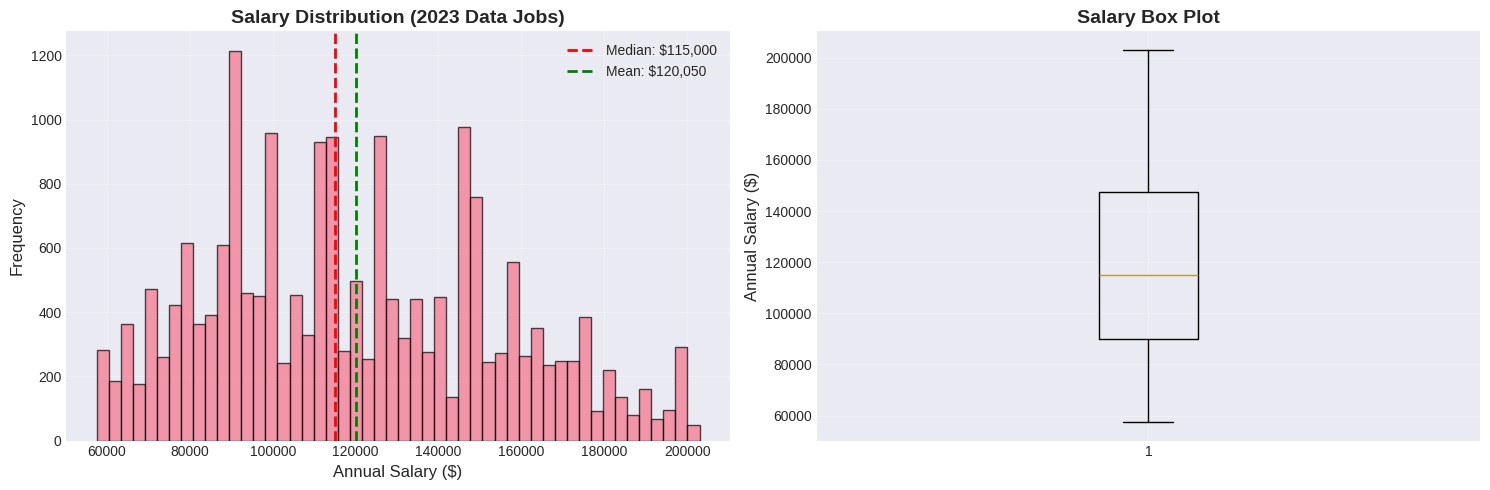

Salary Statistics:
  Mean: $120,050
  Median: $115,000
  Std Dev: $34,787
  Min: $57,500
  Max: $203,000


In [ ]:
# Salary distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_2023['salary'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df_2023['salary'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: ${df_2023["salary"].median():,.0f}')
axes[0].axvline(df_2023['salary'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: ${df_2023["salary"].mean():,.0f}')
axes[0].set_xlabel('Annual Salary ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Salary Distribution (2023 Data Jobs)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(df_2023['salary'], vert=True)
axes[1].set_ylabel('Annual Salary ($)', fontsize=12)
axes[1].set_title('Salary Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Salary Statistics:")
print(f"  Mean: ${df_2023['salary'].mean():,.0f}")
print(f"  Median: ${df_2023['salary'].median():,.0f}")
print(f"  Std Dev: ${df_2023['salary'].std():,.0f}")
print(f"  Min: ${df_2023['salary'].min():,.0f}")
print(f"  Max: ${df_2023['salary'].max():,.0f}")

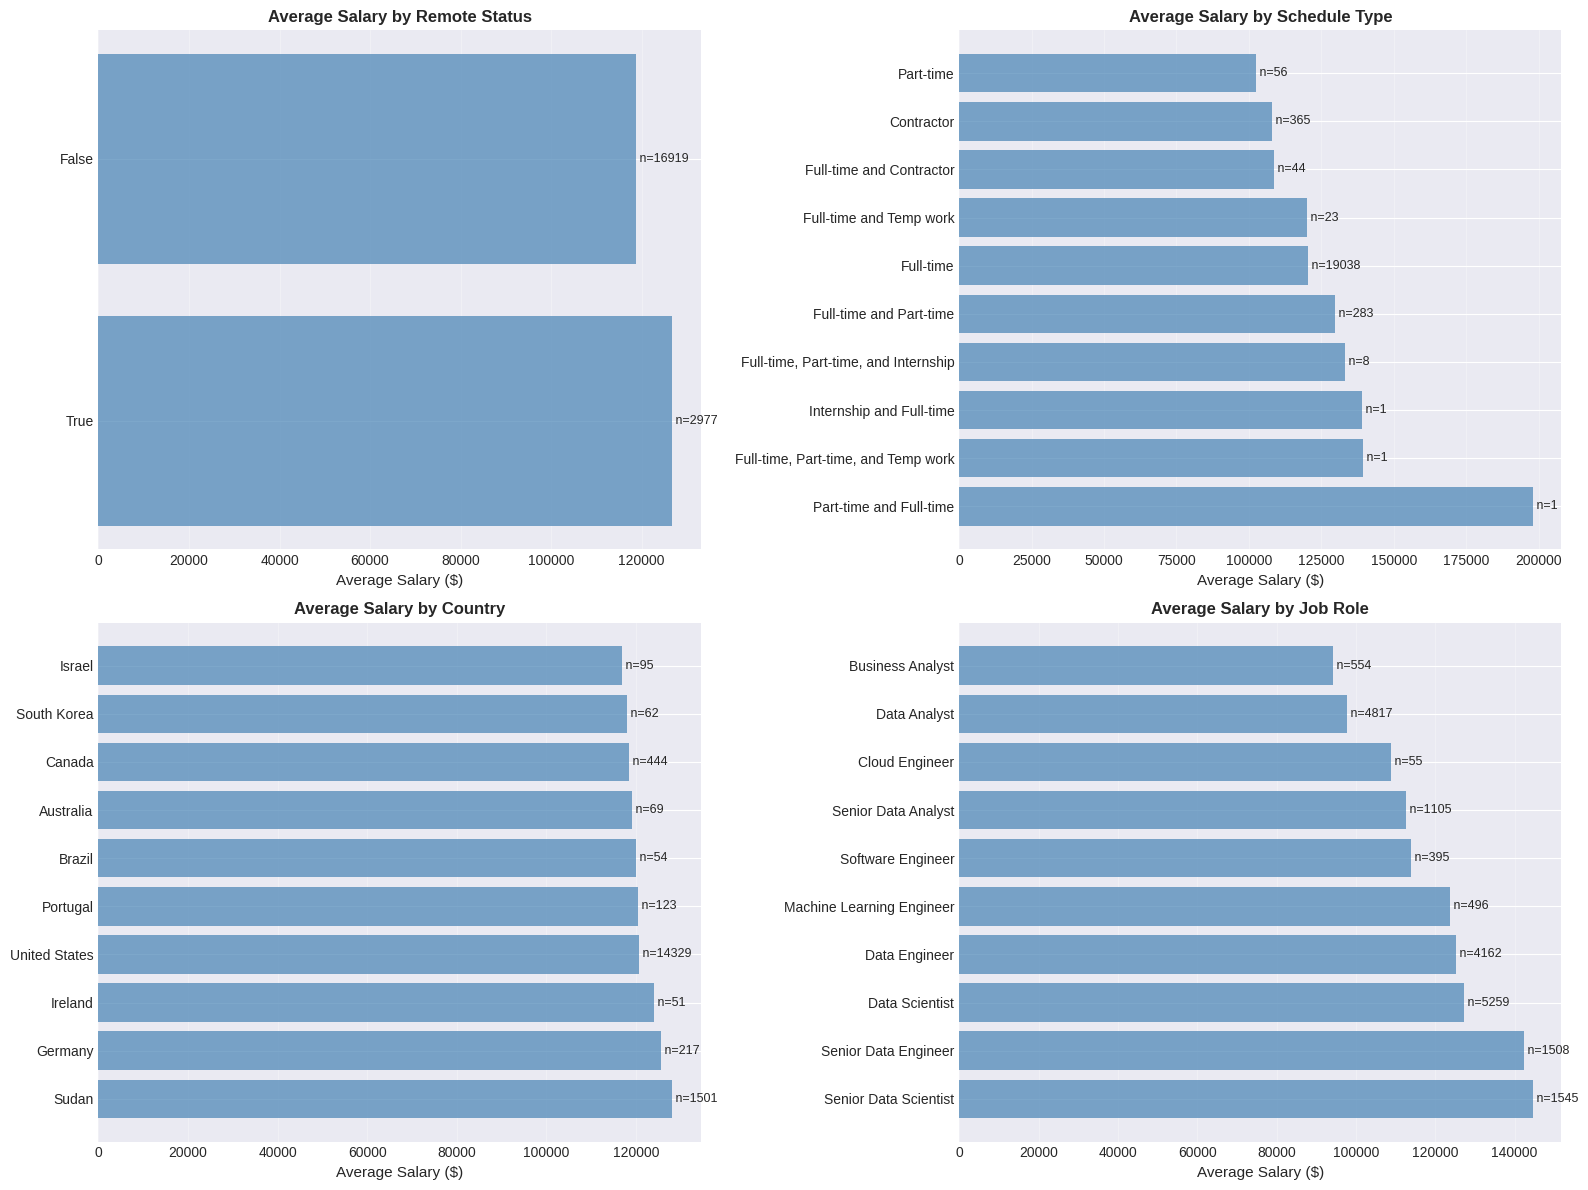

In [ ]:
# Visualize categorical variables vs salary
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

plot_idx = 0

# Plot for each categorical variable
for col in categorical_cols[:4]:  # Plot first 4 categorical variables
    if col in df_2023.columns:
        # Calculate mean salary by category
        salary_by_cat = df_2023.groupby(col)['salary'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)

        # Plot only if there are categories to show
        if len(salary_by_cat) > 0:
            # Limit to top 10 categories for readability
            salary_by_cat_top = salary_by_cat.head(10)

            x_pos = np.arange(len(salary_by_cat_top))
            axes[plot_idx].barh(x_pos, salary_by_cat_top['mean'], alpha=0.7, color='steelblue')
            axes[plot_idx].set_yticks(x_pos)
            axes[plot_idx].set_yticklabels(salary_by_cat_top.index)
            axes[plot_idx].set_xlabel('Average Salary ($)', fontsize=11)
            axes[plot_idx].set_title(f'Average Salary by {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
            axes[plot_idx].grid(axis='x', alpha=0.3)

            # Add count labels
            for i, (idx, row) in enumerate(salary_by_cat_top.iterrows()):
                axes[plot_idx].text(row['mean'], i, f" n={int(row['count'])}", va='center', fontsize=9)

            plot_idx += 1

# Remove unused subplots
for idx in range(plot_idx, 4):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

STATISTICAL ANALYSIS: JOB ATTRIBUTES IMPACT ON SALARY

ATTRIBUTE: REMOTE_STATUS

Descriptive Statistics:
               count       mean    median       std
remote_status                                      
False          16919  118872.82  115000.0  34568.36
True            2977  126742.43  126000.0  35273.54

ANOVA Test:
  F-statistic: 130.3969
  P-value: 4.1640e-30
  Significant: Yes ✓
  Effect size (η²): 0.0065
  Effect interpretation: Negligible

ATTRIBUTE: SCHEDULE_TYPE

Descriptive Statistics:
                                       count       mean     median       std
schedule_type                                                               
Contractor                               365  107853.17  107500.00  30523.29
Contractor and Temp work                   6   86471.60   82500.00  23164.81
Full-time                              19038  120329.88  115000.00  34770.33
Full-time and Contractor                  44  108750.61  108750.00  26982.66
Full-time and Internship       

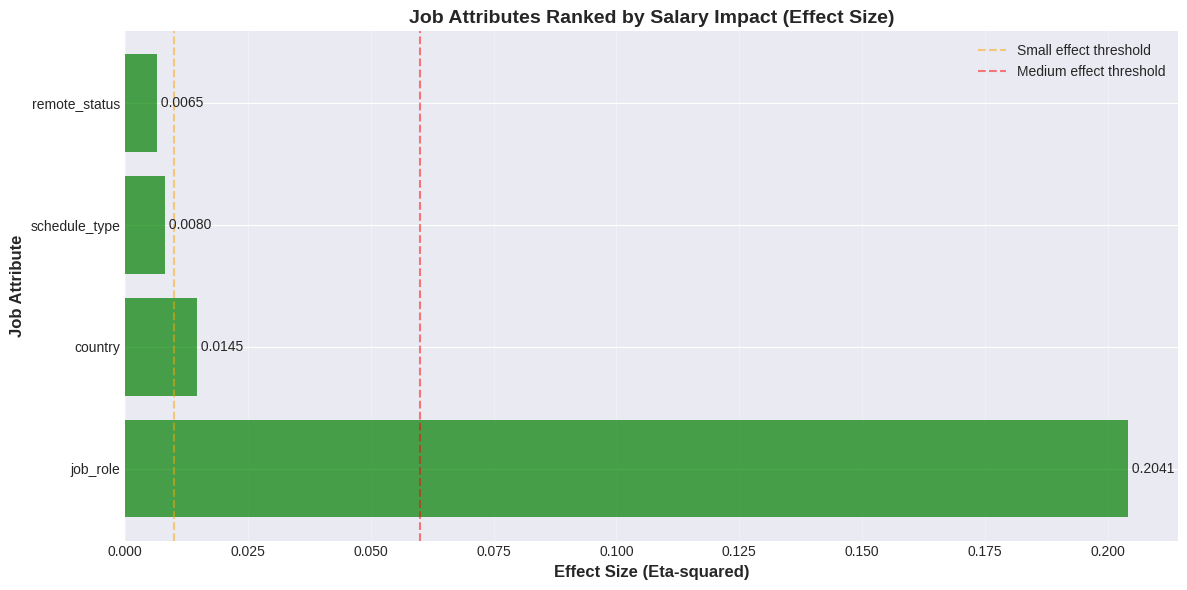

In [ ]:
# Statistical analysis of job attributes impact on salary
print("STATISTICAL ANALYSIS: JOB ATTRIBUTES IMPACT ON SALARY")

attribute_results = []

# Analyze each categorical attribute
for attr in categorical_cols:
    if attr in df_2023.columns:
        print(f"\n{'='*80}")
        print(f"ATTRIBUTE: {attr.upper()}")
        print(f"{'='*80}")

        # Group statistics
        grouped = df_2023.groupby(attr)['salary'].agg([
            ('count', 'count'),
            ('mean', 'mean'),
            ('median', 'median'),
            ('std', 'std')
        ]).round(2)

        print(f"\nDescriptive Statistics:")
        print(grouped.to_string())

        # ANOVA test (if more than 2 categories)
        categories = df_2023[attr].unique()
        if len(categories) >= 2:
            groups = [df_2023[df_2023[attr] == cat]['salary'].values for cat in categories]
            # Filter out empty groups
            groups = [g for g in groups if len(g) > 0]

            if len(groups) >= 2:
                f_stat, p_value = f_oneway(*groups)
                print(f"\nANOVA Test:")
                print(f"  F-statistic: {f_stat:.4f}")
                print(f"  P-value: {p_value:.4e}")
                print(f"  Significant: {'Yes ✓' if p_value < 0.05 else 'No ✗'}")

                # Effect size (Eta squared)
                grand_mean = df_2023['salary'].mean()
                ss_between = sum([len(df_2023[df_2023[attr] == cat]) *
                                 (df_2023[df_2023[attr] == cat]['salary'].mean() - grand_mean)**2
                                 for cat in categories])
                ss_total = sum((df_2023['salary'] - grand_mean)**2)
                eta_squared = ss_between / ss_total if ss_total > 0 else 0

                print(f"  Effect size (η²): {eta_squared:.4f}")

                # Interpret effect size
                if eta_squared < 0.01:
                    effect_interpretation = "Negligible"
                elif eta_squared < 0.06:
                    effect_interpretation = "Small"
                elif eta_squared < 0.14:
                    effect_interpretation = "Medium"
                else:
                    effect_interpretation = "Large"
                print(f"  Effect interpretation: {effect_interpretation}")

                # Store results
                attribute_results.append({
                    'Attribute': attr,
                    'F-statistic': f_stat,
                    'P-value': p_value,
                    'Eta-squared': eta_squared,
                    'Effect_Size': effect_interpretation,
                    'Significant': p_value < 0.05
                })

print("RANKING ATTRIBUTES BY EFFECT SIZE")
# Create summary DataFrame
results_df = pd.DataFrame(attribute_results).sort_values('Eta-squared', ascending=False)
print(results_df.to_string(index=False))

# Visualize effect sizes
if len(results_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['green' if sig else 'gray' for sig in results_df['Significant']]
    bars = ax.barh(results_df['Attribute'], results_df['Eta-squared'], color=colors, alpha=0.7)
    ax.set_xlabel('Effect Size (Eta-squared)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Job Attribute', fontsize=12, fontweight='bold')
    ax.set_title('Job Attributes Ranked by Salary Impact (Effect Size)', fontsize=14, fontweight='bold')
    ax.axvline(0.01, color='orange', linestyle='--', alpha=0.5, label='Small effect threshold')
    ax.axvline(0.06, color='red', linestyle='--', alpha=0.5, label='Medium effect threshold')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, (idx, row) in enumerate(results_df.iterrows()):
        ax.text(row['Eta-squared'], i, f" {row['Eta-squared']:.4f}", va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

INDIVIDUAL SKILLS ANALYSIS

Top 15 Skills by Salary Premium:
     Skill  Count Salary_With Premium_$ Premium_% P-value  Significant
     kafka   1427    $136,358   $17,567     14.8%  0.0000         True
     scala   1659    $136,125   $17,536     14.8%  0.0000         True
   airflow   1358    $135,822   $16,927     14.2%  0.0000         True
    python  11771    $126,946   $16,887     15.3%  0.0000         True
     spark   3569    $133,753   $16,699     14.3%  0.0000         True
tensorflow   1087    $135,179   $16,003     13.4%  0.0000         True
       aws   4532    $131,279   $14,540     12.5%  0.0000         True
  redshift   1372    $133,413   $14,352     12.1%  0.0000         True
 snowflake   2277    $131,801   $13,269     11.2%  0.0000         True
    hadoop   2025    $130,660   $11,812      9.9%  0.0000         True
     nosql   1508    $130,899   $11,738      9.9%  0.0000         True
      java   2483    $130,078   $11,457      9.7%  0.0000         True
       gcp   114

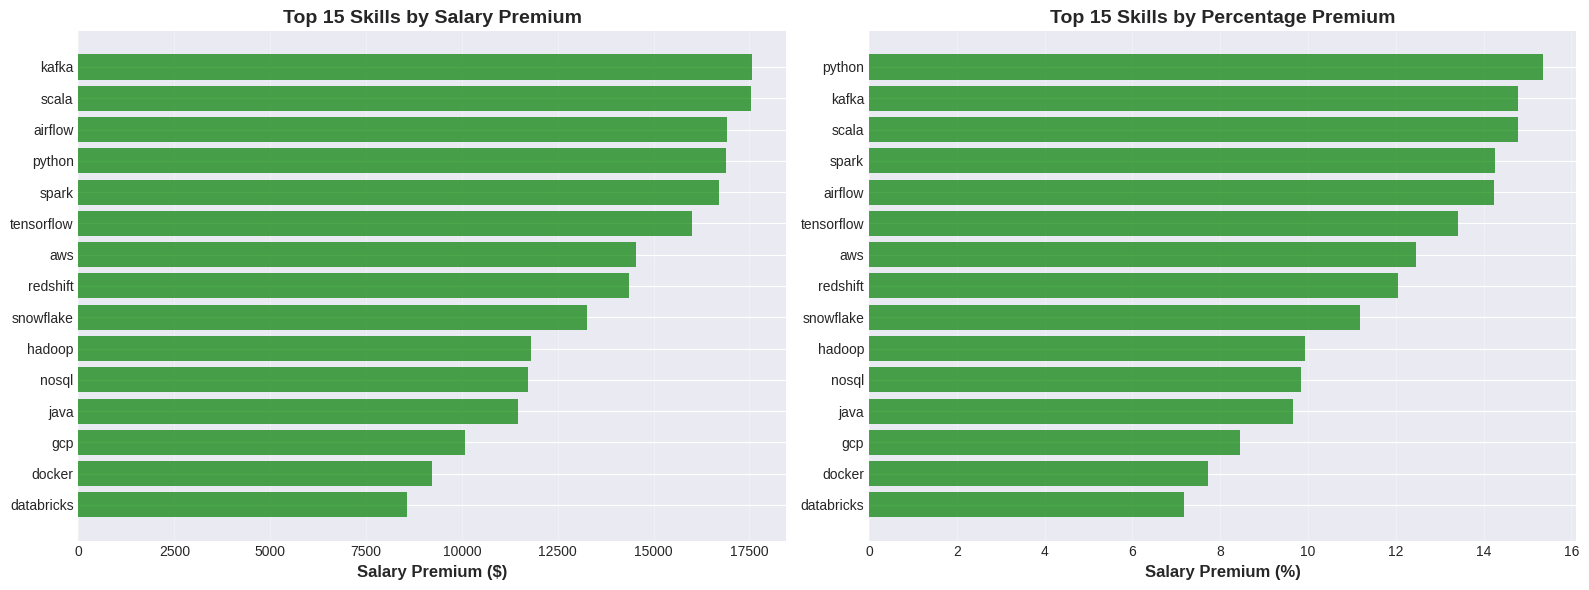


Skills analysis saved to 'skills_salary_analysis.csv'


In [ ]:
# Analyze individual skills impact on salary
print("="*80)
print("INDIVIDUAL SKILLS ANALYSIS")
print("="*80)

if len(common_skills) > 0:
    skill_impacts = []

    for skill in common_skills:
        skill_col = f'skill_{skill}'
        if skill_col in df_2023.columns:
            # Compare salary with and without skill
            with_skill = df_2023[df_2023[skill_col] == 1]['salary']
            without_skill = df_2023[df_2023[skill_col] == 0]['salary']

            if len(with_skill) > 0 and len(without_skill) > 0:
                # Calculate statistics
                mean_with = with_skill.mean()
                mean_without = without_skill.mean()
                premium = mean_with - mean_without
                premium_pct = (premium / mean_without) * 100

                # T-test
                t_stat, p_value = ttest_ind(with_skill, without_skill)

                # Cohen's d (effect size)
                pooled_std = np.sqrt(((len(with_skill)-1)*with_skill.std()**2 +
                                     (len(without_skill)-1)*without_skill.std()**2) /
                                    (len(with_skill) + len(without_skill) - 2))
                cohens_d = (mean_with - mean_without) / pooled_std if pooled_std > 0 else 0

                skill_impacts.append({
                    'Skill': skill,
                    'Count': len(with_skill),
                    'Salary_With': mean_with,
                    'Salary_Without': mean_without,
                    'Premium_$': premium,
                    'Premium_%': premium_pct,
                    'P-value': p_value,
                    'Cohens_d': cohens_d,
                    'Significant': p_value < 0.05
                })

    # Create DataFrame and sort by premium
    skills_df = pd.DataFrame(skill_impacts).sort_values('Premium_$', ascending=False)

    print(f"\nTop 15 Skills by Salary Premium:")
    print("="*80)
    display_cols = ['Skill', 'Count', 'Salary_With', 'Premium_$', 'Premium_%', 'P-value', 'Significant']
    top_skills = skills_df.head(15)[display_cols].copy()
    top_skills['Salary_With'] = top_skills['Salary_With'].apply(lambda x: f'${x:,.0f}')
    top_skills['Premium_$'] = top_skills['Premium_$'].apply(lambda x: f'${x:,.0f}')
    top_skills['Premium_%'] = top_skills['Premium_%'].apply(lambda x: f'{x:.1f}%')
    top_skills['P-value'] = top_skills['P-value'].apply(lambda x: f'{x:.4f}')
    print(top_skills.to_string(index=False))

    # Visualize top skills by premium
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Top 15 skills by absolute premium
    top_15 = skills_df.head(15)
    colors_sig = ['green' if sig else 'gray' for sig in top_15['Significant']]
    axes[0].barh(range(len(top_15)), top_15['Premium_$'], color=colors_sig, alpha=0.7)
    axes[0].set_yticks(range(len(top_15)))
    axes[0].set_yticklabels(top_15['Skill'])
    axes[0].set_xlabel('Salary Premium ($)', fontsize=12, fontweight='bold')
    axes[0].set_title('Top 15 Skills by Salary Premium', fontsize=14, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].invert_yaxis()

    # Top 15 skills by percentage premium
    top_15_pct = skills_df.sort_values('Premium_%', ascending=False).head(15)
    colors_sig_pct = ['green' if sig else 'gray' for sig in top_15_pct['Significant']]
    axes[1].barh(range(len(top_15_pct)), top_15_pct['Premium_%'], color=colors_sig_pct, alpha=0.7)
    axes[1].set_yticks(range(len(top_15_pct)))
    axes[1].set_yticklabels(top_15_pct['Skill'])
    axes[1].set_xlabel('Salary Premium (%)', fontsize=12, fontweight='bold')
    axes[1].set_title('Top 15 Skills by Percentage Premium', fontsize=14, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

    # Save for later use
    skills_df.to_csv('skills_salary_analysis.csv', index=False)
    print("\nSkills analysis saved to 'skills_salary_analysis.csv'")
else:
    print("No skills data available for analysis")
    skills_df = pd.DataFrame()


REGRESSION ANALYSIS: SKILL PREMIUMS CONTROLLING FOR JOB ATTRIBUTES

Fitting OLS regression model...
  Features: 80 (53 controls + 26 skills)
  Observations: 19,896

MODEL SUMMARY
  R-squared: 0.2572
  Adjusted R-squared: 0.2543
  F-statistic: 86.87
  Prob (F-statistic): 0.0000e+00

TOP 15 SKILLS BY SALARY PREMIUM (CONTROLLING FOR ATTRIBUTES)
     Skill Coefficient P-value  Significant
    python      $5,723  0.0000         True
tensorflow      $4,384  0.0000         True
        go      $4,221  0.0000         True
     spark      $4,176  0.0000         True
 snowflake      $3,852  0.0000         True
     kafka      $3,701  0.0002         True
   airflow      $3,501  0.0002         True
     scala      $2,803  0.0023         True
       sql      $2,250  0.0000         True
       aws      $2,175  0.0005         True
     nosql        $319  0.7227        False
   tableau         $31  0.9561        False
  redshift       $-237  0.8077        False
       gcp       $-573  0.5634        F

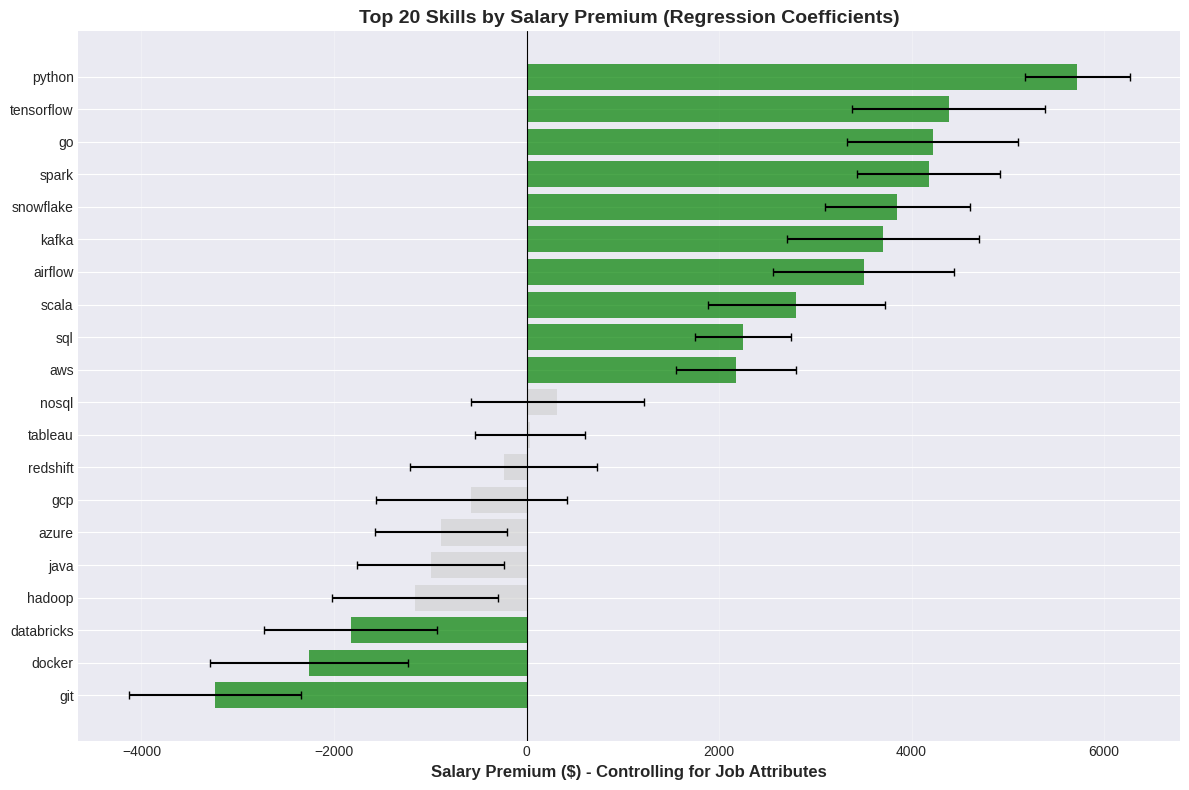


Regression analysis saved to 'skills_regression_analysis.csv'


In [ ]:
# Linear regression to estimate skill premiums while controlling for attributes
print("\n" + "="*80)
print("REGRESSION ANALYSIS: SKILL PREMIUMS CONTROLLING FOR JOB ATTRIBUTES")
print("="*80)

# Prepare data for regression
df_reg = df_2023.copy()

# Create dummy variables for categorical attributes
dummies_list = []
control_vars = []

for attr in categorical_cols:
    if attr in df_reg.columns:
        # Ensure dummy variables are integers (0 or 1)
        dummies = pd.get_dummies(df_reg[attr], prefix=attr, drop_first=True, dtype=int)
        dummies_list.append(dummies)
        control_vars.extend(dummies.columns.tolist())

# Combine all features
if len(dummies_list) > 0:
    X_controls = pd.concat(dummies_list, axis=1)
else:
    X_controls = pd.DataFrame()

# Add skill indicators
skill_cols = [col for col in df_reg.columns if col.startswith('skill_')]
if len(skill_cols) > 0:
    X_skills = df_reg[skill_cols]
    if len(X_controls) > 0:
        X = pd.concat([X_controls, X_skills], axis=1)
    else:
        X = X_skills

    # Add constant
    X = sm.add_constant(X, has_constant='add') # Use has_constant='add' for robustness
    y = df_reg['salary']

    # Fit OLS model
    print("\nFitting OLS regression model...")
    print(f"  Features: {len(X.columns)} ({len(control_vars)} controls + {len(skill_cols)} skills)")
    print(f"  Observations: {len(y):,}")

    model = sm.OLS(y, X).fit()

    # Extract skill coefficients
    skill_coeffs = []
    for skill in common_skills:
        col_name = f'skill_{skill}'
        if col_name in model.params.index:
            coeff = model.params[col_name]
            p_val = model.pvalues[col_name]
            std_err = model.bse[col_name]
            conf_int = model.conf_int().loc[col_name]

            skill_coeffs.append({
                'Skill': skill,
                'Coefficient': coeff,
                'Std_Error': std_err,
                'P-value': p_val,
                'Significant': p_val < 0.05,
                'CI_Lower': conf_int[0],
                'CI_Upper': conf_int[1]
            })

    # Create DataFrame
    skill_reg_df = pd.DataFrame(skill_coeffs).sort_values('Coefficient', ascending=False)

    print(f"\n" + "="*80)
    print("MODEL SUMMARY")
    print("="*80)
    print(f"  R-squared: {model.rsquared:.4f}")
    print(f"  Adjusted R-squared: {model.rsquared_adj:.4f}")
    print(f"  F-statistic: {model.fvalue:.2f}")
    print(f"  Prob (F-statistic): {model.f_pvalue:.4e}")

    print(f"\n" + "="*80)
    print("TOP 15 SKILLS BY SALARY PREMIUM (CONTROLLING FOR ATTRIBUTES)")
    print("="*80)
    top_15_reg = skill_reg_df.head(15).copy()
    top_15_reg['Coefficient'] = top_15_reg['Coefficient'].apply(lambda x: f'${x:,.0f}')
    top_15_reg['P-value'] = top_15_reg['P-value'].apply(lambda x: f'{x:.4f}')
    print(top_15_reg[['Skill', 'Coefficient', 'P-value', 'Significant']].to_string(index=False))

    # Visualize regression coefficients
    fig, ax = plt.subplots(figsize=(12, 8))
    top_20_reg = skill_reg_df.head(20)
    colors_reg = ['green' if sig else 'lightgray' for sig in top_20_reg['Significant']]
    y_pos = range(len(top_20_reg))

    ax.barh(y_pos, top_20_reg['Coefficient'], xerr=top_20_reg['Std_Error'],
            color=colors_reg, alpha=0.7, capsize=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_20_reg['Skill'])
    ax.set_xlabel('Salary Premium ($) - Controlling for Job Attributes', fontsize=12, fontweight='bold')
    ax.set_title('Top 20 Skills by Salary Premium (Regression Coefficients)', fontsize=14, fontweight='bold')
    ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # Save results
    skill_reg_df.to_csv('skills_regression_analysis.csv', index=False)
    print("\nRegression analysis saved to 'skills_regression_analysis.csv'")

else:
    print("No skills data available for regression analysis")


SKILL BUNDLES ANALYSIS

Top 10 Skill Combinations by Salary Premium:
  Skill_1   Skill_2  Frequency Avg_Salary Premium
   python     spark       2922   $134,624 $26,274
   python snowflake       1702   $133,939 $25,053
      aws    python       3638   $132,422 $24,411
     java    python       2182   $130,641 $21,194
    azure    python       2366   $128,402 $19,664
    spark       sql       2470   $134,947 $19,383
      aws       sql       3078   $130,931 $16,429
   python       sql       8361   $126,741 $16,371
snowflake       sql       1863   $131,032 $14,287
   python         r       4319   $122,793 $12,564


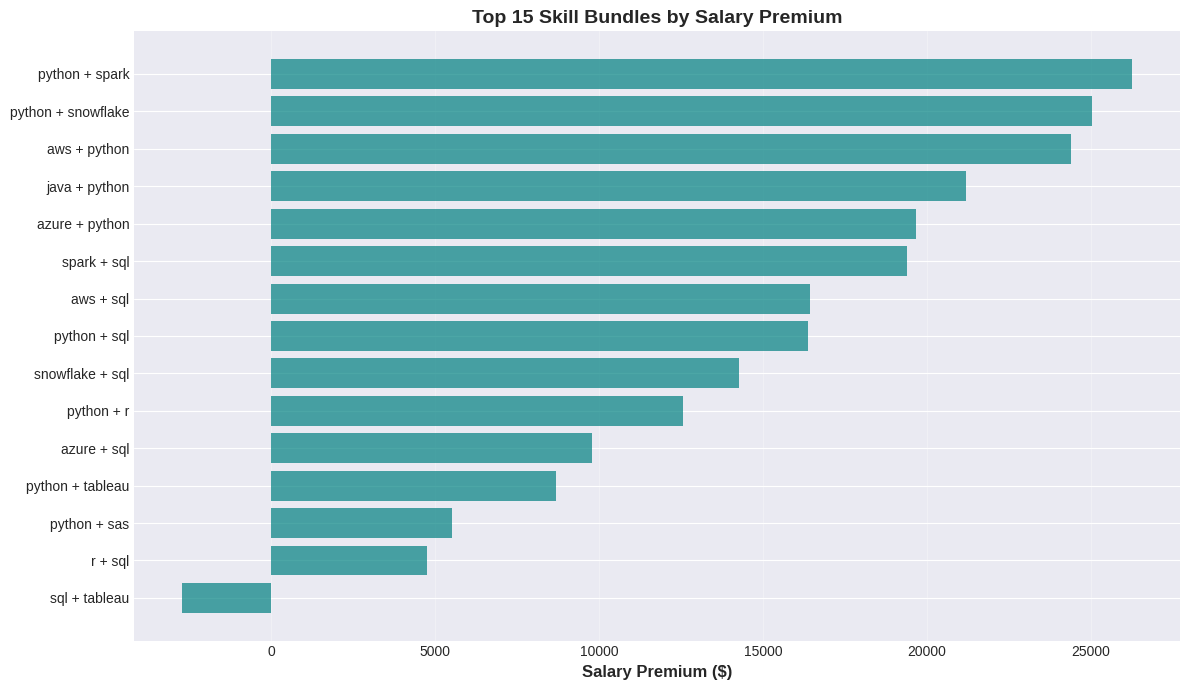


Skill bundles analysis saved to 'skill_bundles_analysis.csv'


In [ ]:
# Analyze common skill bundles/combinations
print("\n" + "="*80)
print("SKILL BUNDLES ANALYSIS")
print("="*80)

if len(common_skills) > 0:
    from itertools import combinations

    # Find most common 2-skill combinations
    skill_pairs = []
    for skills_list in df_2023['skills_list']:
        if len(skills_list) >= 2:
            # Get skills that are in common_skills
            filtered_skills = [s for s in skills_list if s in common_skills]
            if len(filtered_skills) >= 2:
                for pair in combinations(sorted(filtered_skills), 2):
                    skill_pairs.append(pair)

    # Count frequencies
    from collections import Counter
    pair_counts = Counter(skill_pairs)

    # Analyze top combinations
    top_pairs = pair_counts.most_common(20)

    if len(top_pairs) > 0:
        pair_analysis = []

        for (skill1, skill2), count in top_pairs:
            # Find jobs with this combination
            has_both = df_2023['skills_list'].apply(lambda x: skill1 in x and skill2 in x)
            has_none = df_2023['skills_list'].apply(lambda x: skill1 not in x and skill2 not in x)

            salary_with_both = df_2023[has_both]['salary'].mean()
            salary_without = df_2023[has_none]['salary'].mean()
            premium = salary_with_both - salary_without

            pair_analysis.append({
                'Skill_1': skill1,
                'Skill_2': skill2,
                'Frequency': count,
                'Avg_Salary': salary_with_both,
                'Premium': premium
            })

        pairs_df = pd.DataFrame(pair_analysis).sort_values('Premium', ascending=False)

        print(f"\nTop 10 Skill Combinations by Salary Premium:")
        print("="*80)
        top_10_pairs = pairs_df.head(10).copy()
        top_10_pairs['Avg_Salary'] = top_10_pairs['Avg_Salary'].apply(lambda x: f'${x:,.0f}')
        top_10_pairs['Premium'] = top_10_pairs['Premium'].apply(lambda x: f'${x:,.0f}')
        print(top_10_pairs.to_string(index=False))

        # Visualize
        fig, ax = plt.subplots(figsize=(12, 7))
        bundle_labels = [f"{row['Skill_1']} + {row['Skill_2']}" for _, row in pairs_df.head(15).iterrows()]
        ax.barh(range(len(bundle_labels)), pairs_df.head(15)['Premium'], alpha=0.7, color='teal')
        ax.set_yticks(range(len(bundle_labels)))
        ax.set_yticklabels(bundle_labels)
        ax.set_xlabel('Salary Premium ($)', fontsize=12, fontweight='bold')
        ax.set_title('Top 15 Skill Bundles by Salary Premium', fontsize=14, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()

        plt.tight_layout()
        plt.show()

        pairs_df.to_csv('skill_bundles_analysis.csv', index=False)
        print("\nSkill bundles analysis saved to 'skill_bundles_analysis.csv'")
    else:
        print("Not enough skill combinations found")
else:
    print("No skills data available for bundle analysis")

In [ ]:
# Prepare data for machine learning
print("="*80)
print("DATA PREPARATION FOR PREDICTIVE MODELING")
print("="*80)

# Create feature matrix
df_model = df_2023.copy()

# Encode categorical variables
feature_cols = []
encoders = {}

for attr in categorical_cols:
    if attr in df_model.columns:
        le = LabelEncoder()
        df_model[f'{attr}_encoded'] = le.fit_transform(df_model[attr].astype(str))
        feature_cols.append(f'{attr}_encoded')
        encoders[attr] = le

# Add skill features
skill_features = [col for col in df_model.columns if col.startswith('skill_')]
feature_cols.extend(skill_features)

# Add number of skills
if 'num_skills' in df_model.columns:
    feature_cols.append('num_skills')

# Create feature matrix
X = df_model[feature_cols].fillna(0)
y = df_model['salary']

# Create feature names for interpretation
feature_names = []
for col in feature_cols:
    if col.startswith('skill_'):
        feature_names.append(col.replace('skill_', '').replace('_', ' ').title())
    elif col.endswith('_encoded'):
        feature_names.append(col.replace('_encoded', '').replace('_', ' ').title())
    else:
        feature_names.append(col.replace('_', ' ').title())

print(f"\nFeature matrix created")
print(f"  Shape: {X.shape}")
print(f"  Features: {len(feature_cols)}")
print(f"  Target: salary")
print(f"\nFeature types:")
print(f"  Categorical (encoded): {len([c for c in feature_cols if c.endswith('_encoded')])}")
print(f"  Skills: {len(skill_features)}")
print(f"  Numeric: {len([c for c in feature_cols if not c.endswith('_encoded') and not c.startswith('skill_')])}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nData split:")
print(f"  Training set: {X_train.shape[0]:,} samples")
print(f"  Test set: {X_test.shape[0]:,} samples")

DATA PREPARATION FOR PREDICTIVE MODELING

Feature matrix created
  Shape: (19896, 31)
  Features: 31
  Target: salary

Feature types:
  Categorical (encoded): 4
  Skills: 26
  Numeric: 1

Data split:
  Training set: 15,916 samples
  Test set: 3,980 samples



MODEL TRAINING AND EVALUATION

Training Linear Regression...
  Train R²: 0.2084 | Test R²: 0.2046
  Train RMSE: $30,900 | Test RMSE: $31,224
  Train MAE: $25,169 | Test MAE: $25,667

Training Ridge Regression...
  Train R²: 0.2084 | Test R²: 0.2046
  Train RMSE: $30,900 | Test RMSE: $31,224
  Train MAE: $25,169 | Test MAE: $25,667

Training Random Forest...
  Train R²: 0.5255 | Test R²: 0.2848
  Train RMSE: $23,922 | Test RMSE: $29,609
  Train MAE: $18,677 | Test MAE: $23,683

Training Gradient Boosting...
  Train R²: 0.3538 | Test R²: 0.2729
  Train RMSE: $27,917 | Test RMSE: $29,854
  Train MAE: $22,537 | Test MAE: $24,148

Training XGBoost...
  Train R²: 0.3490 | Test R²: 0.2740
  Train RMSE: $28,020 | Test RMSE: $29,832
  Train MAE: $22,600 | Test MAE: $24,167

Training LightGBM...
  Train R²: 0.3318 | Test R²: 0.2733
  Train RMSE: $28,388 | Test RMSE: $29,845
  Train MAE: $22,922 | Test MAE: $24,182

MODEL COMPARISON
            Model  Train_R2  Test_R2   Train_RMSE    Test_RMSE 

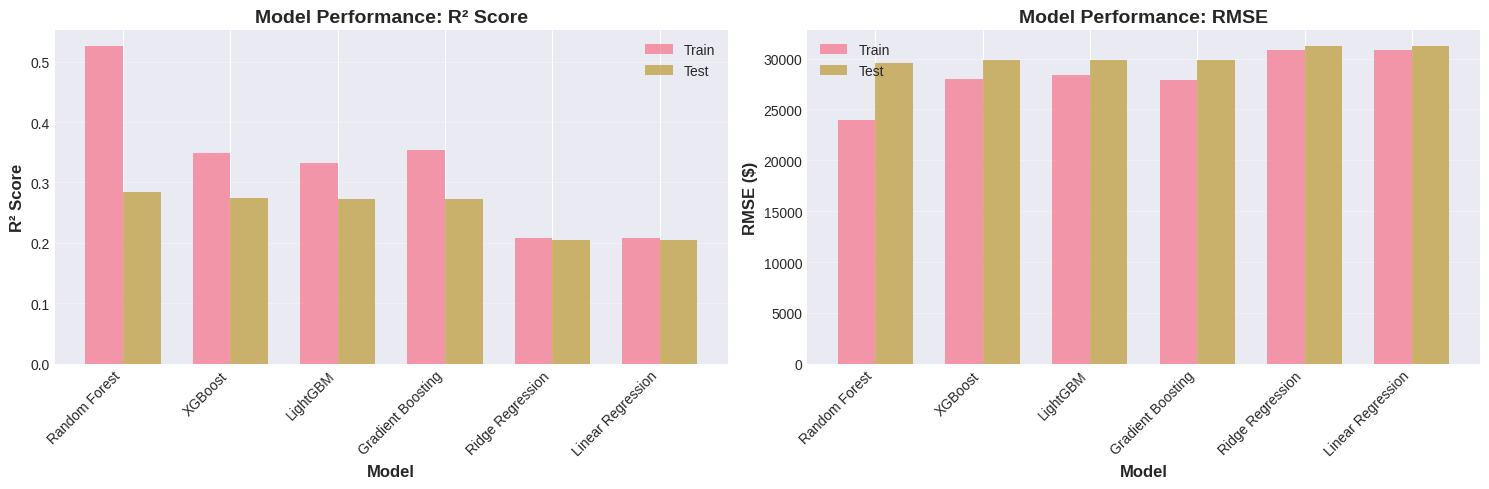


Best performing model: Random Forest
  Test R²: 0.2848
  Test RMSE: $29,609


In [ ]:
# Train multiple models
print("\n" + "="*80)
print("MODEL TRAINING AND EVALUATION")
print("="*80)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Evaluate
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)

    results.append({
        'Model': name,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae
    })

    print(f"  Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
    print(f"  Train RMSE: ${train_rmse:,.0f} | Test RMSE: ${test_rmse:,.0f}")
    print(f"  Train MAE: ${train_mae:,.0f} | Test MAE: ${test_mae:,.0f}")

# Create results DataFrame
results_df = pd.DataFrame(results).sort_values('Test_R2', ascending=False)

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(results_df.to_string(index=False))

# Visualize model performance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R² scores
x = range(len(results_df))
width = 0.35
axes[0].bar([i - width/2 for i in x], results_df['Train_R2'], width, label='Train', alpha=0.7)
axes[0].bar([i + width/2 for i in x], results_df['Test_R2'], width, label='Test', alpha=0.7)
axes[0].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Model Performance: R² Score', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# RMSE
axes[1].bar([i - width/2 for i in x], results_df['Train_RMSE'], width, label='Train', alpha=0.7)
axes[1].bar([i + width/2 for i in x], results_df['Test_RMSE'], width, label='Test', alpha=0.7)
axes[1].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE ($)', fontsize=12, fontweight='bold')
axes[1].set_title('Model Performance: RMSE', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Select best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\nBest performing model: {best_model_name}")
print(f"  Test R²: {results_df.iloc[0]['Test_R2']:.4f}")
print(f"  Test RMSE: ${results_df.iloc[0]['Test_RMSE']:,.0f}")


FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features (Random Forest):
      Feature  Importance
     Job Role    0.393757
   Num Skills    0.111537
      Country    0.096831
Remote Status    0.022612
        Excel    0.022066
       Python    0.021678
          Sql    0.021483
     Power Bi    0.017137
Schedule Type    0.016725
           Go    0.016720
      Tableau    0.016622
          Aws    0.016500
            R    0.016490
        Spark    0.016414
        Azure    0.015099
    Snowflake    0.014201
         Java    0.014028
          Sas    0.013125
       Oracle    0.011966
        Scala    0.011742


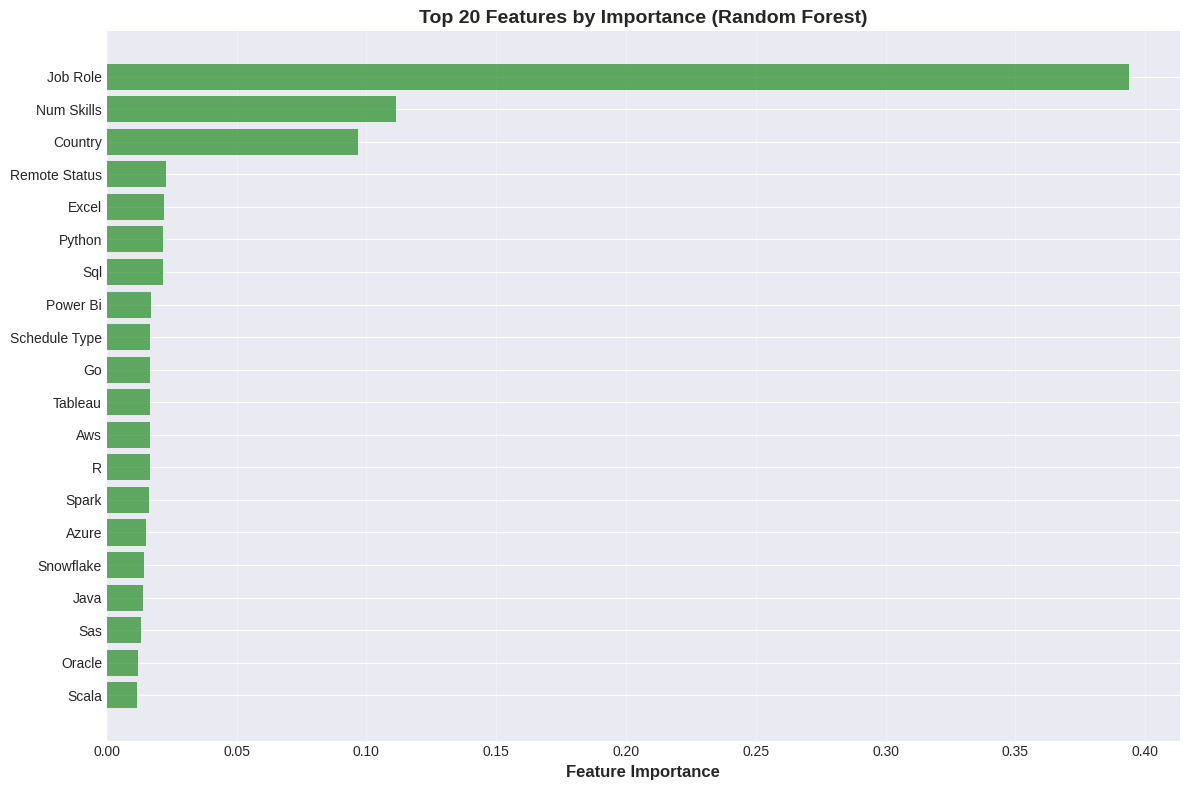


Feature importance breakdown:
  Total skills importance: 0.8717 (87.2%)
  Total attributes importance: 0.1283 (12.8%)

Feature importance saved to 'feature_importance.csv'


In [ ]:
# Feature importance from tree-based models
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Use Random Forest for feature importance (usually most stable)
rf_model = models['Random Forest']

# Get feature importances
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features (Random Forest):")
print("="*80)
top_20_features = feature_importance_df.head(20)
print(top_20_features.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(top_20_features)), top_20_features['Importance'], alpha=0.7, color='forestgreen')
ax.set_yticks(range(len(top_20_features)))
ax.set_yticklabels(top_20_features['Feature'])
ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Features by Importance (Random Forest)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Categorize features
skill_importance = feature_importance_df[feature_importance_df['Feature'].str.lower().apply(
    lambda x: any(skill in x.lower() for skill in common_skills) if common_skills else False
)]
attribute_importance = feature_importance_df[~feature_importance_df['Feature'].isin(skill_importance['Feature'])]

print(f"\nFeature importance breakdown:")
print(f"  Total skills importance: {skill_importance['Importance'].sum():.4f} ({skill_importance['Importance'].sum()/feature_importance_df['Importance'].sum()*100:.1f}%)")
print(f"  Total attributes importance: {attribute_importance['Importance'].sum():.4f} ({attribute_importance['Importance'].sum()/feature_importance_df['Importance'].sum()*100:.1f}%)")

# Save
feature_importance_df.to_csv('feature_importance.csv', index=False)
print("\nFeature importance saved to 'feature_importance.csv'")

SHAP ANALYSIS: MODEL EXPLAINABILITY

Computing SHAP values (this may take a few minutes)...
SHAP values computed for 1000 test samples
SHAP SUMMARY


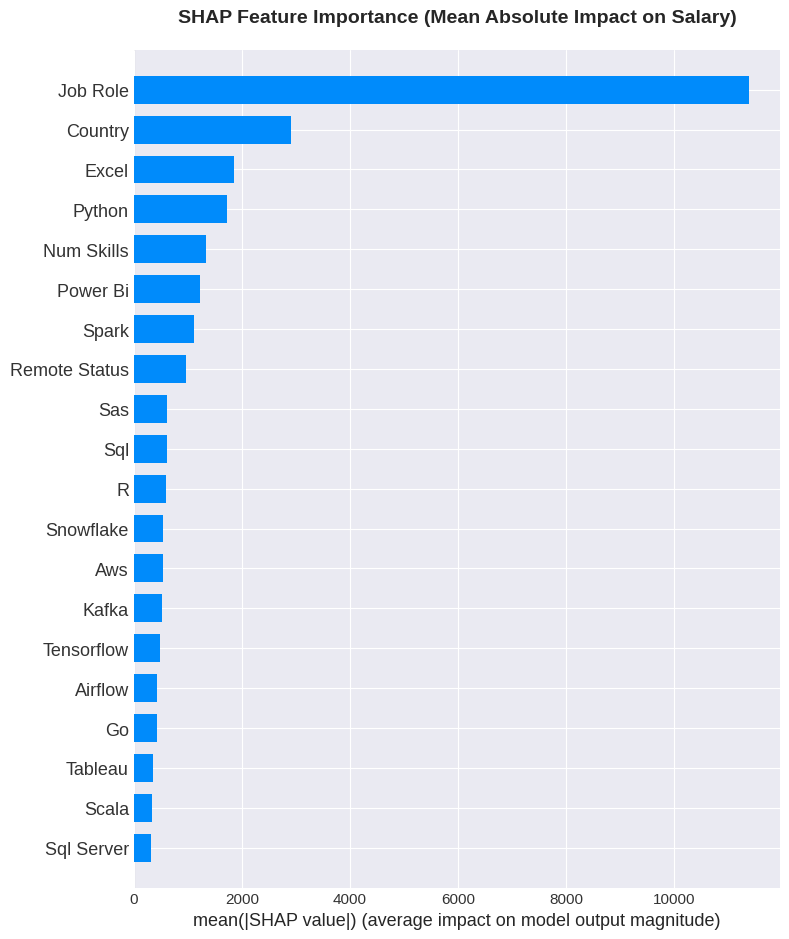

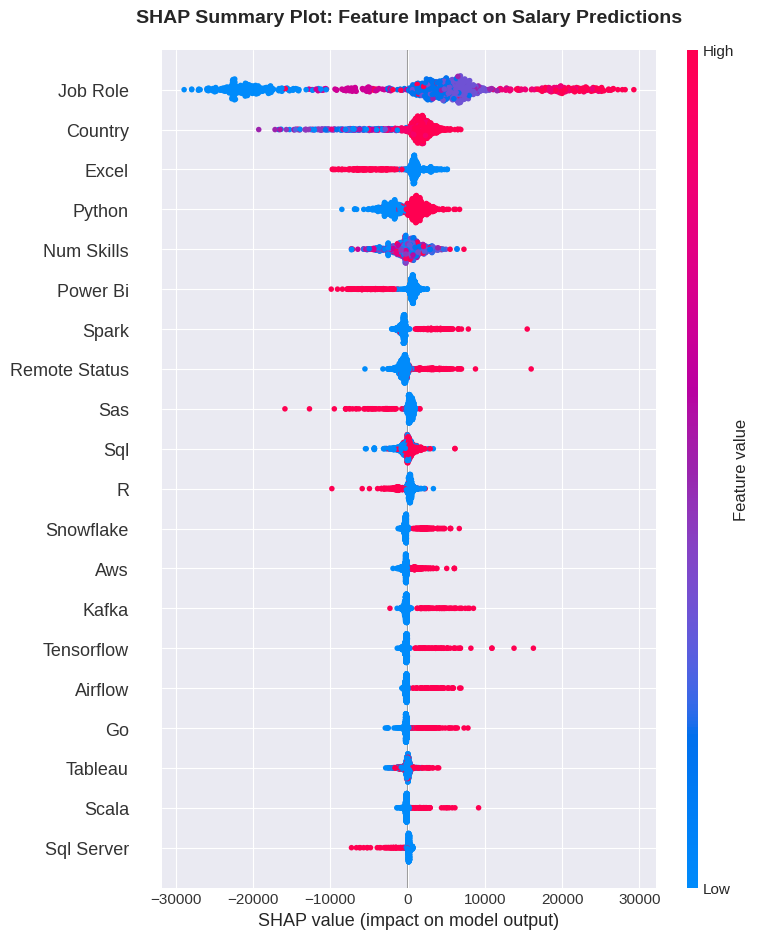


Top 20 Features by SHAP Importance:
      Feature  Mean_Abs_SHAP
     Job Role   11382.456873
      Country    2908.389940
        Excel    1851.169730
       Python    1717.641472
   Num Skills    1335.434740
     Power Bi    1223.295835
        Spark    1106.428807
Remote Status     961.955974
          Sas     622.122890
          Sql     609.781056
            R     590.358123
    Snowflake     545.252254
          Aws     530.394446
        Kafka     524.716177
   Tensorflow     478.890747
      Airflow     435.352151
           Go     426.845035
      Tableau     359.865566
        Scala     338.666687
   Sql Server     322.409002

SHAP importance saved to 'shap_importance.csv'


In [ ]:
# SHAP Analysis for Model Explainability
print("SHAP ANALYSIS: MODEL EXPLAINABILITY")

print("\nComputing SHAP values (this may take a few minutes)...")

# Use tree-based explainer for Random Forest (faster)
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for test set (use sample if too large)
sample_size = min(1000, len(X_test))
X_test_sample = X_test.sample(n=sample_size, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print(f"SHAP values computed for {sample_size} test samples")

# Create feature names DataFrame for easier interpretation
X_test_sample_named = X_test_sample.copy()
X_test_sample_named.columns = feature_names

print("SHAP SUMMARY")
# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample_named, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Mean Absolute Impact on Salary)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Detailed summary plot
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_sample_named, show=False)
plt.title('SHAP Summary Plot: Feature Impact on Salary Predictions', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Calculate mean absolute SHAP values
shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Abs_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False)

print("\nTop 20 Features by SHAP Importance:")
print("="*80)
print(shap_importance.head(20).to_string(index=False))

# Save SHAP importance
shap_importance.to_csv('shap_importance.csv', index=False)
print("\nSHAP importance saved to 'shap_importance.csv'")

SHAP DEPENDENCE PLOTS: TOP SALARY DRIVERS


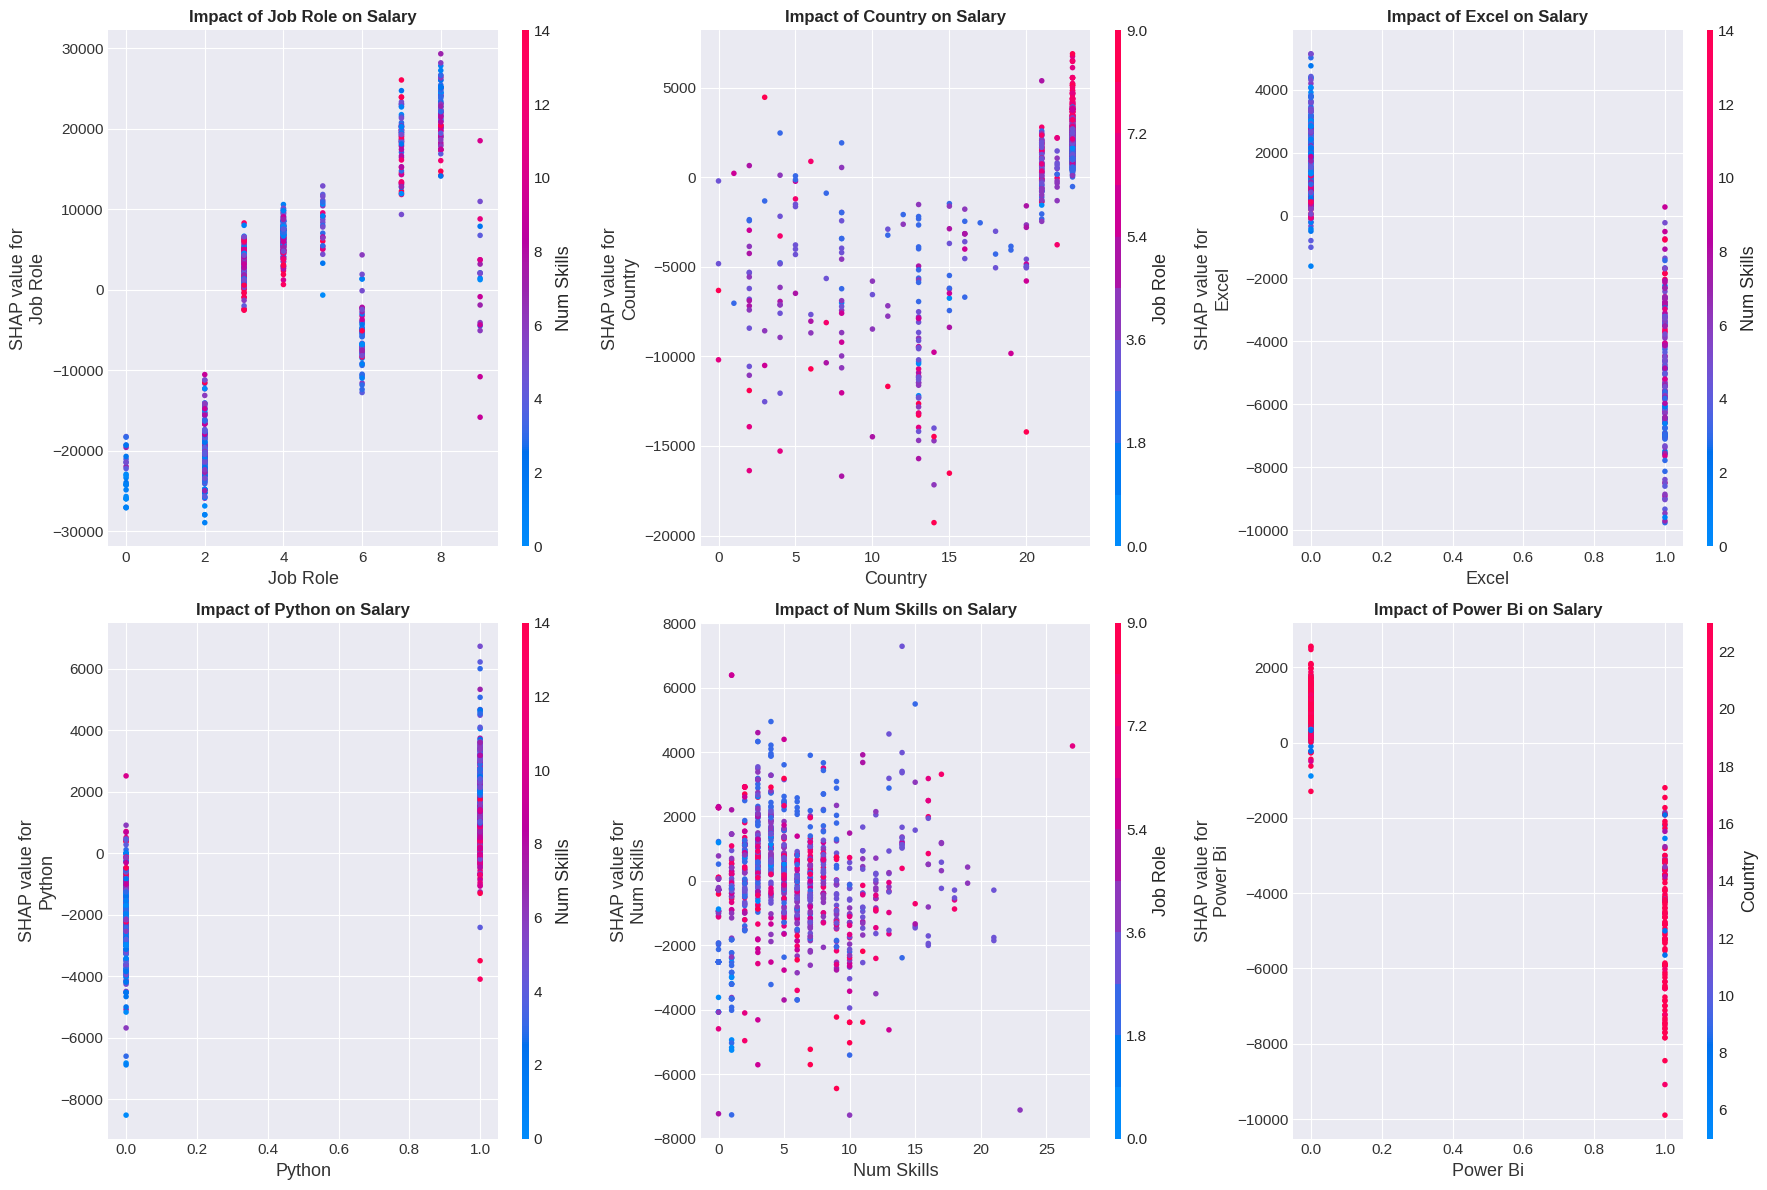


SHAP dependence plots show how each feature value affects salary predictions


In [ ]:
# SHAP Dependence Plots for Top Features
print("SHAP DEPENDENCE PLOTS: TOP SALARY DRIVERS")

# Get top 6 features
top_features = shap_importance.head(6)['Feature'].tolist()
top_feature_indices = [feature_names.index(f) for f in top_features]

# Create dependence plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (feature_name, feature_idx) in enumerate(zip(top_features, top_feature_indices)):
    ax = axes[idx]
    shap.dependence_plot(
        feature_idx,
        shap_values,
        X_test_sample_named,
        ax=ax,
        show=False
    )
    ax.set_title(f'Impact of {feature_name} on Salary', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSHAP dependence plots show how each feature value affects salary predictions")

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

print("HYPERPARAMETER TUNING")
print("Using 5-fold CV  |  Scoring: R²  |  GridSearchCV=Ridge  |  RandomizedSearchCV=rest")
print()

tuned_results = {}

# 1. Ridge Regression (GridSearchCV – small search space)
print("─" * 60)
print("[1/6] Ridge Regression  →  GridSearchCV")
ridge_param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]}
ridge_gs = GridSearchCV(
    Ridge(), ridge_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=0
)
ridge_gs.fit(X_train, y_train)
tuned_results['Ridge Regression'] = {
    'best_params': ridge_gs.best_params_,
    'best_cv_r2': ridge_gs.best_score_,
    'model': ridge_gs.best_estimator_
}
print(f"  Best params : {ridge_gs.best_params_}")
print(f"  Best CV R²  : {ridge_gs.best_score_:.4f}")

# 2. Random Forest (RandomizedSearchCV)
print("─" * 60)
print("[2/6] Random Forest  →  RandomizedSearchCV (n_iter=30)")
rf_param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', 0.5, 0.7]
}
rf_rs = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=30, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
rf_rs.fit(X_train, y_train)
tuned_results['Random Forest'] = {
    'best_params': rf_rs.best_params_,
    'best_cv_r2': rf_rs.best_score_,
    'model': rf_rs.best_estimator_
}
print(f"  Best params : {rf_rs.best_params_}")
print(f"  Best CV R²  : {rf_rs.best_score_:.4f}")

# 3. Gradient Boosting (RandomizedSearchCV)
print("─" * 60)
print("[3/6] Gradient Boosting  →  RandomizedSearchCV (n_iter=30)")
gb_param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}
gb_rs = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_dist,
    n_iter=30, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
gb_rs.fit(X_train, y_train)
tuned_results['Gradient Boosting'] = {
    'best_params': gb_rs.best_params_,
    'best_cv_r2': gb_rs.best_score_,
    'model': gb_rs.best_estimator_
}
print(f"  Best params : {gb_rs.best_params_}")
print(f"  Best CV R²  : {gb_rs.best_score_:.4f}")

# 4. XGBoost (RandomizedSearchCV)
print("─" * 60)
print("[4/6] XGBoost  →  RandomizedSearchCV (n_iter=30)")
xgb_param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'min_child_weight': randint(1, 10),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0.5, 2)
}
xgb_rs = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    xgb_param_dist,
    n_iter=30, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
xgb_rs.fit(X_train, y_train)
tuned_results['XGBoost'] = {
    'best_params': xgb_rs.best_params_,
    'best_cv_r2': xgb_rs.best_score_,
    'model': xgb_rs.best_estimator_
}
print(f"  Best params : {xgb_rs.best_params_}")
print(f"  Best CV R²  : {xgb_rs.best_score_:.4f}")

# 5. LightGBM (RandomizedSearchCV)
print("─" * 60)
print("[5/6] LightGBM  →  RandomizedSearchCV (n_iter=30)")
lgb_param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': [3, 4, 5, 6, 8, -1],
    'learning_rate': uniform(0.01, 0.3),
    'num_leaves': randint(20, 150),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'min_child_samples': randint(5, 50),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 2)
}
lgb_rs = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    lgb_param_dist,
    n_iter=30, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
lgb_rs.fit(X_train, y_train)
tuned_results['LightGBM'] = {
    'best_params': lgb_rs.best_params_,
    'best_cv_r2': lgb_rs.best_score_,
    'model': lgb_rs.best_estimator_
}
print(f"  Best params : {lgb_rs.best_params_}")
print(f"  Best CV R²  : {lgb_rs.best_score_:.4f}")

# 6. Linear Regression – no hyperparameters; shown for completeness
print("─" * 60)
print("[6/6] Linear Regression  →  No tunable hyperparameters (reported from CV)")
lr_cv_r2 = cross_val_score(LinearRegression(), X_train, y_train, cv=5, scoring='r2').mean()
tuned_results['Linear Regression'] = {
    'best_params': {},
    'best_cv_r2': lr_cv_r2,
    'model': LinearRegression().fit(X_train, y_train)
}
print(f"  CV R²  : {lr_cv_r2:.4f}")

HYPERPARAMETER TUNING
Using 5-fold CV  |  Scoring: R²  |  GridSearchCV=Ridge  |  RandomizedSearchCV=rest

────────────────────────────────────────────────────────────
[1/6] Ridge Regression  →  GridSearchCV
  Best params : {'alpha': 100.0}
  Best CV R²  : 0.2054
────────────────────────────────────────────────────────────
[2/6] Random Forest  →  RandomizedSearchCV (n_iter=30)
  Best params : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 13, 'n_estimators': 107}
  Best CV R²  : 0.2905
────────────────────────────────────────────────────────────
[3/6] Gradient Boosting  →  RandomizedSearchCV (n_iter=30)
  Best params : {'learning_rate': np.float64(0.027425083650459835), 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 201, 'subsample': np.float64(0.8603553891795411)}
  Best CV R²  : 0.2826
────────────────────────────────────────────────────────────
[4/6] XGBoost  →  RandomizedSearchCV (n_iter=30)
  Best params : {'col

TUNED MODEL EVALUATION ON TEST SET

Model                   Baseline R²     Tuned R²    R² Gain  Baseline RMSE     Tuned RMSE
------------------------------------------------------------------------------------------
Random Forest                0.2848       0.2971    +0.0124         29,609         29,352
XGBoost                      0.2740       0.2848    +0.0108         29,832         29,609
Gradient Boosting            0.2729       0.2812    +0.0083         29,854         29,684
LightGBM                     0.2733       0.2789    +0.0056         29,845         29,730
Ridge Regression             0.2046       0.2048    +0.0002         31,224         31,221
Linear Regression            0.2046       0.2046    +0.0000         31,224         31,224


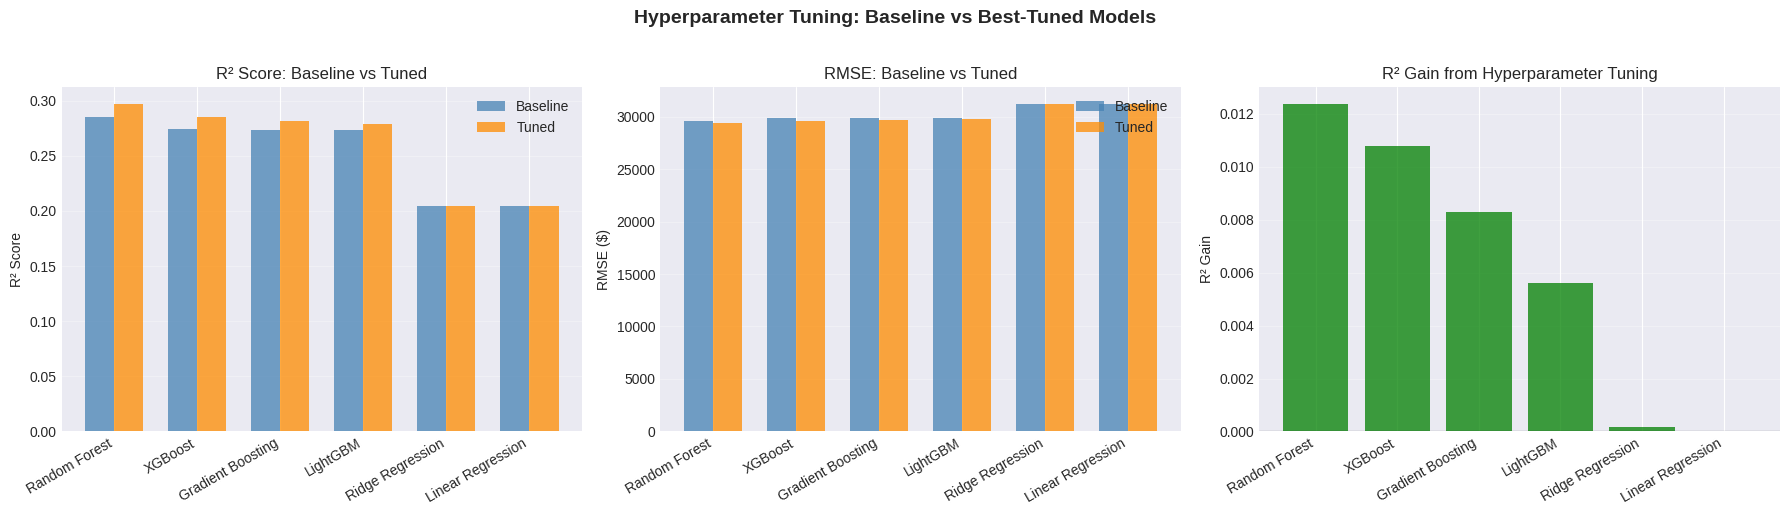


Best tuned model  : Random Forest
  Tuned Test R²   : 0.2971
  Tuned Test RMSE : $29,352
  Best params     : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 13, 'n_estimators': 107}


In [ ]:
# Evaluate tuned models on the held-out test set
print("TUNED MODEL EVALUATION ON TEST SET")

tuned_eval = []

for name, info in tuned_results.items():
    tuned_model = info['model']
    y_pred = tuned_model.predict(X_test)

    t_r2   = r2_score(y_test, y_pred)
    t_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    t_mae  = mean_absolute_error(y_test, y_pred)

    # Baseline metrics (from the results_df built earlier)
    baseline_row = results_df[results_df['Model'] == name]
    b_r2   = baseline_row['Test_R2'].values[0]   if len(baseline_row) else np.nan
    b_rmse = baseline_row['Test_RMSE'].values[0] if len(baseline_row) else np.nan

    tuned_eval.append({
        'Model':          name,
        'Baseline_R2':    b_r2,
        'Tuned_R2':       t_r2,
        'R2_Gain':        t_r2 - b_r2,
        'Baseline_RMSE':  b_rmse,
        'Tuned_RMSE':     t_rmse,
        'Tuned_MAE':      t_mae
    })

tuned_eval_df = pd.DataFrame(tuned_eval).sort_values('Tuned_R2', ascending=False)

print("\n{:<22} {:>12} {:>12} {:>10} {:>14} {:>14}".format(
    'Model', 'Baseline R²', 'Tuned R²', 'R² Gain', 'Baseline RMSE', 'Tuned RMSE'))
print("-" * 90)
for _, row in tuned_eval_df.iterrows():
    gain_str = f"+{row['R2_Gain']:.4f}" if row['R2_Gain'] >= 0 else f"{row['R2_Gain']:.4f}"
    print("{:<22} {:>12.4f} {:>12.4f} {:>10} {:>14,.0f} {:>14,.0f}".format(
        row['Model'], row['Baseline_R2'], row['Tuned_R2'], gain_str,
        row['Baseline_RMSE'], row['Tuned_RMSE']))

# Visualise comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(tuned_eval_df))
width = 0.35

# R²
axes[0].bar(x - width/2, tuned_eval_df['Baseline_R2'], width, label='Baseline', alpha=0.75, color='steelblue')
axes[0].bar(x + width/2, tuned_eval_df['Tuned_R2'],    width, label='Tuned',    alpha=0.75, color='darkorange')
axes[0].set_xticks(x); axes[0].set_xticklabels(tuned_eval_df['Model'], rotation=30, ha='right')
axes[0].set_ylabel('R² Score'); axes[0].set_title('R² Score: Baseline vs Tuned')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# RMSE
axes[1].bar(x - width/2, tuned_eval_df['Baseline_RMSE'], width, label='Baseline', alpha=0.75, color='steelblue')
axes[1].bar(x + width/2, tuned_eval_df['Tuned_RMSE'],    width, label='Tuned',    alpha=0.75, color='darkorange')
axes[1].set_xticks(x); axes[1].set_xticklabels(tuned_eval_df['Model'], rotation=30, ha='right')
axes[1].set_ylabel('RMSE ($)'); axes[1].set_title('RMSE: Baseline vs Tuned')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

# R² Gain (improvement from tuning)
gain_colors = ['green' if g >= 0 else 'red' for g in tuned_eval_df['R2_Gain']]
axes[2].bar(x, tuned_eval_df['R2_Gain'], color=gain_colors, alpha=0.75)
axes[2].set_xticks(x); axes[2].set_xticklabels(tuned_eval_df['Model'], rotation=30, ha='right')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_ylabel('R² Gain'); axes[2].set_title('R² Gain from Hyperparameter Tuning')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Hyperparameter Tuning: Baseline vs Best-Tuned Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Best tuned model
best_tuned_name = tuned_eval_df.iloc[0]['Model']
best_tuned_model = tuned_results[best_tuned_name]['model']
print(f"\nBest tuned model  : {best_tuned_name}")
print(f"  Tuned Test R²   : {tuned_eval_df.iloc[0]['Tuned_R2']:.4f}")
print(f"  Tuned Test RMSE : ${tuned_eval_df.iloc[0]['Tuned_RMSE']:,.0f}")
print(f"  Best params     : {tuned_results[best_tuned_name]['best_params']}")